
# MTGFlow (AAAI 2023) — 


In [1]:

# %%
# 0) Imports & environment

import os
import re
import sys
import random
from typing import Optional

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from torch.nn.utils import clip_grad_value_
import matplotlib.pyplot as plt

# Reproducibility
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cpu



## 1) Configuration

Update these values to match your local setup.


In [2]:

# %%
# 1) Configuration

# SMD folder (your provided path)
DATA_ROOT = r"C:\Users\S4027872\OneDrive - RMIT University\Desktop\My-Study\Anomaly detection\code\mtad-gat-independent\SMD"

# Dimensionality (you used DIM=38 successfully)
DIM = 38

# If you loaded dataset_params earlier, set VALID_RATIO from it; otherwise keep 0.0
try:
    VALID_RATIO = float(dataset_params.get("valid_ratio", 0.0))
except Exception:
    VALID_RATIO = 0.0

# If you loaded model_params earlier, read window/stride from it; otherwise set manually
try:
    window_size = int(model_params.get("window_size", 100))
    stride = int(model_params.get("stride", 1))
except Exception:
    window_size = 100
    stride = 1

# Choose which entity to run (0..27)
ENTITY_INDEX = 0

# MTGFlow repo path (place MTGFLOW-main next to this notebook)
MTGFLOW_REPO_PATH = "./MTGFLOW-main"   # change if needed

# Training hyperparameters
BATCH_SIZE = 256
EPOCHS = 10         # start with 10; increase to 40 after confirming it runs
LR = 2e-3
WEIGHT_DECAY = 5e-4
GRAD_CLIP = 1.0

print("DATA_ROOT:", DATA_ROOT)
print("DIM:", DIM, "VALID_RATIO:", VALID_RATIO)
print("window_size:", window_size, "stride:", stride)
print("ENTITY_INDEX:", ENTITY_INDEX)
print("MTGFLOW_REPO_PATH:", MTGFLOW_REPO_PATH)


DATA_ROOT: C:\Users\S4027872\OneDrive - RMIT University\Desktop\My-Study\Anomaly detection\code\mtad-gat-independent\SMD
DIM: 38 VALID_RATIO: 0.0
window_size: 100 stride: 1
ENTITY_INDEX: 0
MTGFLOW_REPO_PATH: ./MTGFLOW-main



## 2) Detect available SMD entities (from filenames)

We expect files like:
- `<entity>_train.pkl`
- `<entity>_test.pkl`
- `<entity>_test_label.pkl`


In [3]:

# %%
# 2) Detect entities from the SMD folder

files = sorted([f for f in os.listdir(DATA_ROOT) if os.path.isfile(os.path.join(DATA_ROOT, f))])
print(f"Found {len(files)} files. First 20:")
for f in files[:20]:
    print("  ", f)

pattern = re.compile(r"^(?P<entity>.+)_(?P<split>train|test|test_label)\.(?P<ext>pkl)$")
matches = [pattern.match(f) for f in files]
matches = [m for m in matches if m is not None]

if not matches:
    raise FileNotFoundError("No <entity>_(train|test|test_label).pkl files found in DATA_ROOT.")

entities_all = sorted(set(m.group("entity") for m in matches))
print("\nDetected entities:", len(entities_all))
print("First 15:", entities_all[:15])

entity = entities_all[ENTITY_INDEX]
print("\nUsing entity:", entity)

TRAIN_POSTFIX = "train.pkl"
TEST_POSTFIX = "test.pkl"
TEST_LABEL_POSTFIX = "test_label.pkl"

for postfix in [TRAIN_POSTFIX, TEST_POSTFIX, TEST_LABEL_POSTFIX]:
    p = os.path.join(DATA_ROOT, f"{entity}_{postfix}")
    print("Check exists:", os.path.basename(p), "->", os.path.exists(p))


Found 85 files. First 20:
   .DS_Store
   machine-1-1_test.pkl
   machine-1-1_test_label.pkl
   machine-1-1_train.pkl
   machine-1-2_test.pkl
   machine-1-2_test_label.pkl
   machine-1-2_train.pkl
   machine-1-3_test.pkl
   machine-1-3_test_label.pkl
   machine-1-3_train.pkl
   machine-1-4_test.pkl
   machine-1-4_test_label.pkl
   machine-1-4_train.pkl
   machine-1-5_test.pkl
   machine-1-5_test_label.pkl
   machine-1-5_train.pkl
   machine-1-6_test.pkl
   machine-1-6_test_label.pkl
   machine-1-6_train.pkl
   machine-1-7_test.pkl

Detected entities: 28
First 15: ['machine-1-1', 'machine-1-2', 'machine-1-3', 'machine-1-4', 'machine-1-5', 'machine-1-6', 'machine-1-7', 'machine-1-8', 'machine-2-1', 'machine-2-2', 'machine-2-3', 'machine-2-4', 'machine-2-5', 'machine-2-6', 'machine-2-7']

Using entity: machine-1-1
Check exists: machine-1-1_train.pkl -> True
Check exists: machine-1-1_test.pkl -> True
Check exists: machine-1-1_test_label.pkl -> True



## 3) Load **one** entity using mtad-tools `load_dataset`

This avoids loading and windowing all 28 entities at once.


In [4]:

# %%
# 3) Load one entity using your mtad-tools loader

from dataloader import load_dataset

data_dict_one = load_dataset(
    data_root=DATA_ROOT,
    entities=[entity],              # IMPORTANT: only one entity
    valid_ratio=VALID_RATIO,
    dim=DIM,
    test_label_postfix=TEST_LABEL_POSTFIX,
    test_postfix=TEST_POSTFIX,
    train_postfix=TRAIN_POSTFIX,
)

sub = data_dict_one[entity]

train_ts = sub["train"].astype(np.float32, copy=False)              # [N_train, DIM]
test_ts  = sub["test"].astype(np.float32, copy=False)               # [N_test, DIM]
test_label_point = sub["test_label"].astype(np.int64, copy=False)   # [N_test]

print("train_ts:", train_ts.shape)
print("test_ts :", test_ts.shape)
print("test_label_point:", test_label_point.shape, "anomaly_ratio=", float(test_label_point.mean()))


train_ts: (28479, 38)
test_ts : (28479, 38)
test_label_point: (28479,) anomaly_ratio= 0.09459601811861372



## 4) On-the-fly window dataset (no materializing)

Each sample yields:
- `x`: `[K, T, 1]` float tensor for MTGFlow
- `y`: window label (1 if any point label in the window is 1)


In [5]:

# %%
# 4) On-the-fly window dataset

class OnTheFlyWindowDataset(Dataset):
    def __init__(self, ts: np.ndarray, window_size: int, stride: int, labels: Optional[np.ndarray] = None):
        assert ts.ndim == 2, "ts must be [N, K]"
        self.ts = ts.astype(np.float32, copy=False)
        self.labels = None if labels is None else labels.astype(np.int64, copy=False)
        self.T = int(window_size)
        self.S = int(stride)
        self.N = ts.shape[0]
        self.K = ts.shape[1]

        self.n_windows = 1 + (self.N - self.T) // self.S
        if self.n_windows <= 0:
            raise ValueError("Time series shorter than window_size.")

    def __len__(self):
        return self.n_windows

    def __getitem__(self, idx: int):
        start = idx * self.S
        end = start + self.T
        w = self.ts[start:end, :]  # [T, K]

        # MTGFlow expects [K, T, 1]
        x = torch.from_numpy(w).transpose(0, 1).unsqueeze(-1)

        if self.labels is None:
            y = 0
        else:
            y = int(self.labels[start:end].sum() > 0)

        return x, y, idx

train_ds = OnTheFlyWindowDataset(train_ts, window_size=window_size, stride=stride, labels=None)
test_ds  = OnTheFlyWindowDataset(test_ts,  window_size=window_size, stride=stride, labels=test_label_point)

print("Train windows:", len(train_ds), "Test windows:", len(test_ds))

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # safest on Windows
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


Train windows: 28380 Test windows: 28380



## 5) Build MTGFlow model

We infer `K` and `T` from a batch.


In [6]:

# %%
# 5) MTGFlow model creation

if MTGFLOW_REPO_PATH not in sys.path:
    sys.path.insert(0, MTGFLOW_REPO_PATH)

from models.MTGFLOW import MTGFLOW

xb, yb, _ = next(iter(train_loader))
K = xb.shape[1]
T = xb.shape[2]
print("K (features):", K, "T (window):", T)

# MTGFlow hyperparameters (tune as needed)
N_BLOCKS = 2          # often 2 for SMD-style datasets
HIDDEN_SIZE = 32
N_HIDDEN = 1

model = MTGFLOW(
    n_blocks=N_BLOCKS,
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    n_hidden=N_HIDDEN,
    window_size=T,
    n_sensor=K,
    dropout=0.0,
    model="MAF",
    batch_norm=False,
).to(DEVICE)

print("MTGFlow parameters:", sum(p.numel() for p in model.parameters()))

optimizer = torch.optim.Adam(
    [{"params": model.parameters(), "weight_decay": WEIGHT_DECAY}],
    lr=LR,
    weight_decay=0.0,
)


K (features): 38 T (window): 100
MTGFlow parameters: 42336



## 6) Evaluation (window-level AUROC)

MTGFlow outputs log-likelihood. We use **NLL = -loglik** as anomaly score (higher = more anomalous).


In [7]:

# %%
def evaluate_auc(model, loader):
    model.eval()
    scores = []
    labels = []
    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(DEVICE)
            nll = (-model.test(x)).detach().cpu().numpy().reshape(-1)  # anomaly score
            scores.append(nll)
            labels.append(np.asarray(y, dtype=np.int64).reshape(-1))
    scores = np.concatenate(scores)
    labels = np.concatenate(labels)
    auc = roc_auc_score(labels, scores)
    return auc, scores, labels



## 7) Train MTGFlow


In [8]:

# %%
history = {"train_nll": [], "test_auc": []}
best_auc = -1.0
best_state = None

for epoch in range(EPOCHS):
    model.train()
    losses = []

    for x, _, _ in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()

        loss = -model(x)  # maximize log-likelihood
        loss.backward()
        clip_grad_value_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        losses.append(float(loss.item()))

    train_nll = float(np.mean(losses))
    test_auc, _, _ = evaluate_auc(model, test_loader)

    history["train_nll"].append(train_nll)
    history["test_auc"].append(float(test_auc))

    if test_auc > best_auc:
        best_auc = float(test_auc)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | train NLL={train_nll:.4f} | test AUROC={test_auc:.4f} | best={best_auc:.4f}")

# Restore best epoch weights
if best_state is not None:
    model.load_state_dict(best_state)


Epoch 001/10 | train NLL=-2.9351 | test AUROC=0.5501 | best=0.5501
Epoch 002/10 | train NLL=-2.5311 | test AUROC=0.6958 | best=0.6958
Epoch 003/10 | train NLL=-3.9888 | test AUROC=0.2184 | best=0.6958
Epoch 004/10 | train NLL=-4.9296 | test AUROC=0.3882 | best=0.6958
Epoch 005/10 | train NLL=-3.1070 | test AUROC=0.8863 | best=0.8863
Epoch 006/10 | train NLL=-4.9012 | test AUROC=0.8083 | best=0.8863
Epoch 007/10 | train NLL=-4.8337 | test AUROC=0.6480 | best=0.8863
Epoch 008/10 | train NLL=-5.2753 | test AUROC=0.3310 | best=0.8863
Epoch 009/10 | train NLL=-2.1134 | test AUROC=0.5145 | best=0.8863
Epoch 010/10 | train NLL=-4.8037 | test AUROC=0.4098 | best=0.8863



## 8) Plot curves and final evaluation


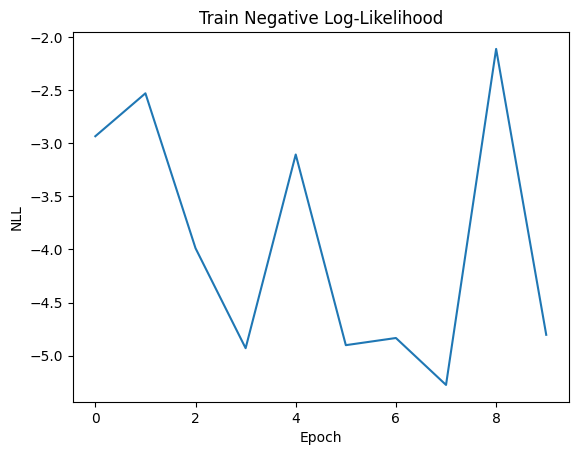

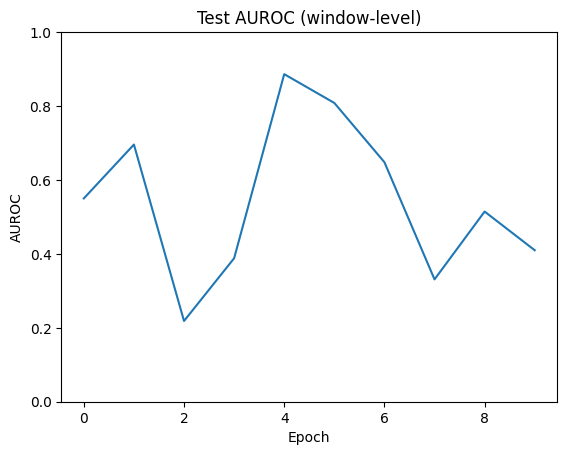

Final (best-restored) AUROC: 0.8862630392796611


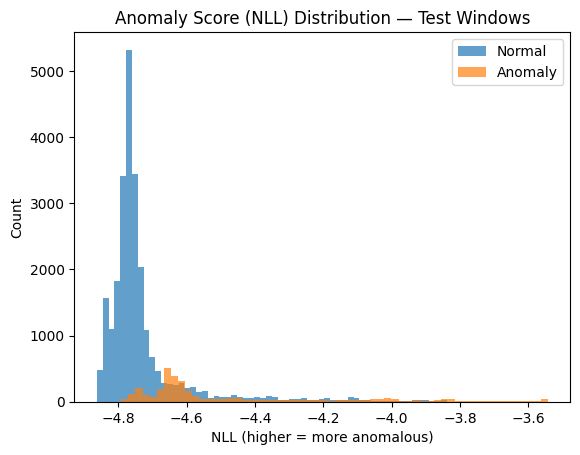

In [9]:

# %%
plt.figure()
plt.plot(history["train_nll"])
plt.title("Train Negative Log-Likelihood")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.show()

plt.figure()
plt.plot(history["test_auc"])
plt.title("Test AUROC (window-level)")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.ylim(0.0, 1.0)
plt.show()

final_auc, scores, labels = evaluate_auc(model, test_loader)
print("Final (best-restored) AUROC:", final_auc)

plt.figure()
plt.hist(scores[labels == 0], bins=60, alpha=0.7, label="Normal")
plt.hist(scores[labels == 1], bins=60, alpha=0.7, label="Anomaly")
plt.title("Anomaly Score (NLL) Distribution — Test Windows")
plt.xlabel("NLL (higher = more anomalous)")
plt.ylabel("Count")
plt.legend()
plt.show()



## 9) Optional: inspect top anomalous windows

This plots a few sensors for the most anomalous windows.


Top anomalous window indices: [17398, 17399, 17400, 17402, 17401]
Scores: [-3.5431230068206787, -3.543156385421753, -3.544036388397217, -3.5447843074798584, -3.5448265075683594]
Labels: [1, 1, 1, 1, 1]


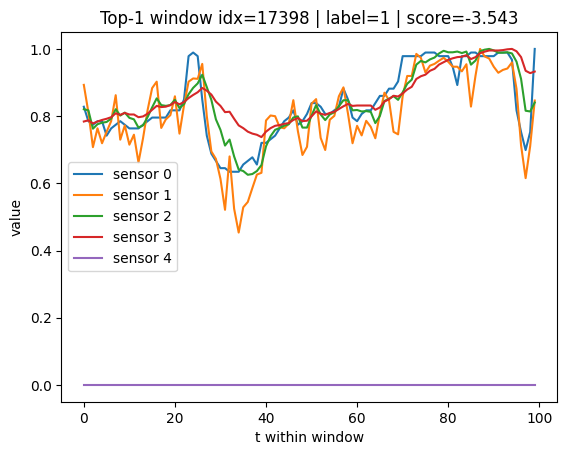

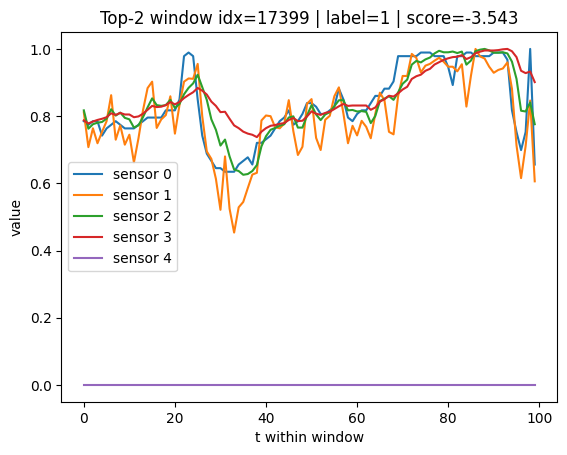

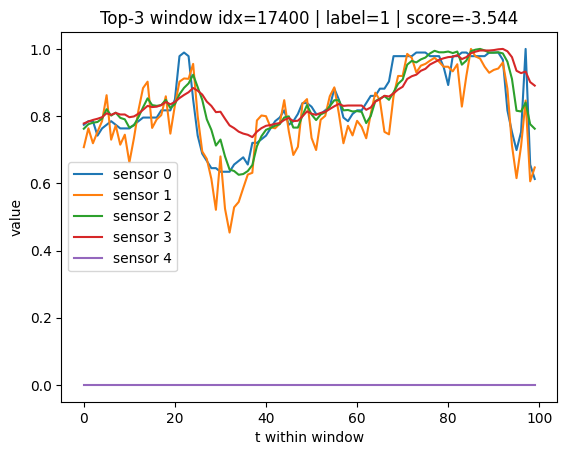

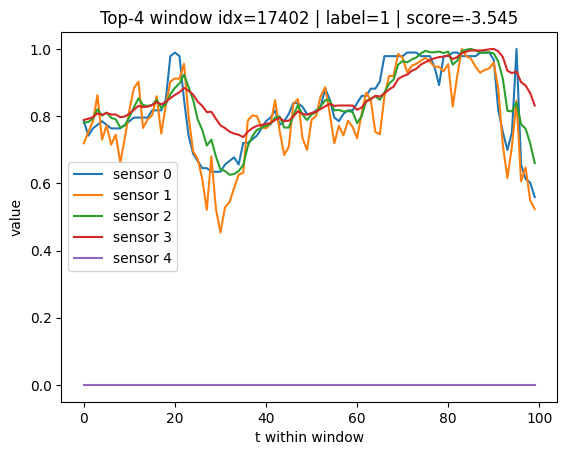

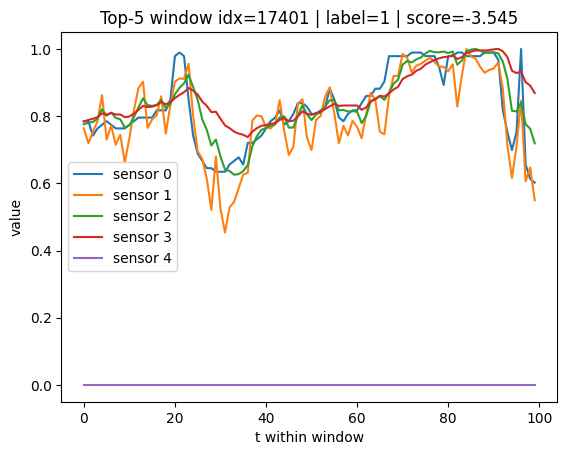

In [10]:

# %%
top_k = 5
final_auc, scores, labels = evaluate_auc(model, test_loader)
top_idx = np.argsort(-scores)[:top_k]

print("Top anomalous window indices:", top_idx.tolist())
print("Scores:", [float(scores[i]) for i in top_idx])
print("Labels:", [int(labels[i]) for i in top_idx])

# Plot first 5 sensors for each top window
n_plot_sensors = min(5, DIM)

for rank, idx in enumerate(top_idx, start=1):
    start = int(idx) * stride
    end = start + window_size
    w = test_ts[start:end, :]  # [T, K]

    plt.figure()
    for k in range(n_plot_sensors):
        plt.plot(np.arange(window_size), w[:, k], label=f"sensor {k}")
    plt.title(f"Top-{rank} window idx={idx} | label={labels[idx]} | score={scores[idx]:.3f}")
    plt.xlabel("t within window")
    plt.ylabel("value")
    plt.legend()
    plt.show()


Window scores: (28380,) min/max: -4.862295150756836 -3.5431230068206787
Threshold (th): -3.769201920342445


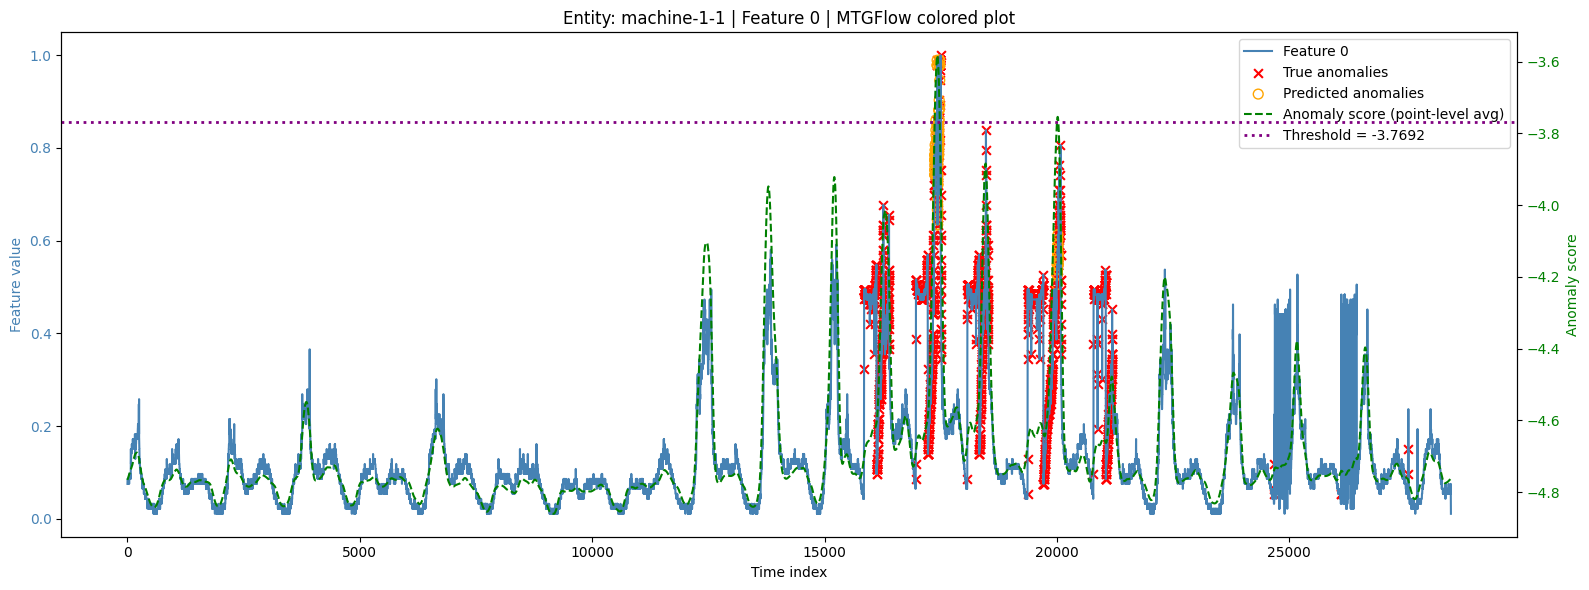

In [11]:
#same as mtad-gat:

# %%
import numpy as np
import matplotlib.pyplot as plt
import torch

# -----------------------------
# 1) Get full test series and labels (point-level)
# -----------------------------
test_series_full = test_ts                      # shape [T, D]
test_labels_full = test_label_point             # shape [T]
T_total, D = test_series_full.shape

W = window_size
S = stride

# -----------------------------
# 2) Compute window-level anomaly scores for ALL test windows (NLL)
#    Use idx to place scores in the correct order
# -----------------------------
model.eval()
n_windows = len(test_ds)
test_anomaly_score = np.zeros(n_windows, dtype=np.float64)

with torch.no_grad():
    for x, _, idx in test_loader:
        x = x.to(DEVICE)
        # anomaly score = NLL = -loglik
        batch_scores = (-model.test(x)).detach().cpu().numpy().reshape(-1)
        idx = np.asarray(idx, dtype=np.int64).reshape(-1)
        test_anomaly_score[idx] = batch_scores

print("Window scores:", test_anomaly_score.shape, "min/max:", test_anomaly_score.min(), test_anomaly_score.max())

# -----------------------------
# 3) Expand window-level scores into point-level scores
#    (average scores of all windows covering each time point)
# -----------------------------
point_scores = np.zeros(T_total, dtype=np.float64)
point_counts = np.zeros(T_total, dtype=np.float64)

for i, score in enumerate(test_anomaly_score):
    start = i * S
    end = start + W
    if start >= T_total:
        break
    if end > T_total:
        end = T_total
    point_scores[start:end] += score
    point_counts[start:end] += 1.0

mask = point_counts > 0
point_scores[mask] /= point_counts[mask]

# -----------------------------
# 4) Choose a threshold (pick ONE approach)
# -----------------------------
# A) Simple percentile threshold on point scores (common unsupervised choice)
th = np.quantile(point_scores[mask], 0.995)   # adjust 0.99 / 0.995 / 0.999

# B) Or use train window scores percentile (often better)
# (uncomment if you want train-based threshold)
# train_scores = []
# model.eval()
# with torch.no_grad():
#     for x, _, _ in train_loader:
#         x = x.to(DEVICE)
#         train_scores.append((-model.test(x)).detach().cpu().numpy().reshape(-1))
# train_scores = np.concatenate(train_scores)
# th = np.quantile(train_scores, 0.995)

print("Threshold (th):", float(th))

# -----------------------------
# 5) Derive point-level predictions
# -----------------------------
point_pred = np.zeros(T_total, dtype=np.int64)
point_pred[mask] = (point_scores[mask] >= th).astype(np.int64)

# -----------------------------
# 6) Plot one feature with true anomalies, predicted anomalies, and anomaly score
# -----------------------------
feature_idx = 0  # change this
ts = test_series_full[:, feature_idx]
time_idx = np.arange(T_total)

fig, ax1 = plt.subplots(figsize=(16, 6))

# Raw time series
ax1.plot(time_idx, ts, color="steelblue", label=f"Feature {feature_idx}")

# True anomalies (red x)
true_anom_idx = np.where(test_labels_full == 1)[0]
ax1.scatter(true_anom_idx, ts[true_anom_idx], color="red", marker="x", s=40, label="True anomalies")

# Predicted anomalies (orange circles)
pred_anom_idx = np.where(point_pred == 1)[0]
ax1.scatter(pred_anom_idx, ts[pred_anom_idx], facecolors="none", edgecolors="orange",
            marker="o", s=50, label="Predicted anomalies")

ax1.set_xlabel("Time index")
ax1.set_ylabel("Feature value", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Right axis: anomaly score
ax2 = ax1.twinx()
ax2.plot(time_idx, point_scores, color="green", linestyle="--", label="Anomaly score (point-level avg)")

# Threshold line
ax2.axhline(th, color="purple", linestyle=":", linewidth=2, label=f"Threshold = {th:.4f}")
ax2.set_ylabel("Anomaly score", color="green")
ax2.tick_params(axis="y", labelcolor="green")

# Merge legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(f"Entity: {entity} | Feature {feature_idx} | MTGFlow colored plot")
plt.tight_layout()
plt.show()
